# Decision tree classifier — combined datasets

This notebook:

1. loads the existing classifier-input pickles for the training, validation, and test datasets,
2. merges them into one dataframe,
3. makes the same random stratified train/test split as the original notebook,
4. trains and evaluates the decision tree.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


# The notebook works when Jupyter is started either in the repository root
# or directly inside the classifier directory.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "classifier").exists():
    if (REPO_ROOT.parent / "classifier").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError(
            "Could not find the classifier directory. Start Jupyter from "
            "the repository root or from the classifier directory."
        )

In [2]:
QRS_ANNOTATIONS = {
    "N", "L", "R", "V", "/", "A", "f", "F",
    "a", "J", "S", "e", "j", "E", "Q",
}

GROUPING_SCHEMES = {
    "current": {
        "N": {"N"},
        "A": {"A"},
        "V": {"V"},
        "R": {"R"},
        "L": {"L"},
        "/": {"/"},
        "Other": QRS_ANNOTATIONS - {"N", "A", "V", "R", "L", "/"},
    },

    "aami": {
        "N": {"N", "L", "R", "e", "j"},
        "S": {"A", "a", "J", "S"},
        "V": {"V", "E"},
        "F": {"F"},
        "Q": {"/", "f", "Q"},
    },
}


def group_annotations(annotation_series, scheme):
    if scheme not in GROUPING_SCHEMES:
        raise ValueError(
            f"Unknown grouping scheme: {scheme!r}. "
            f"Available schemes: {list(GROUPING_SCHEMES)}"
        )

    groups = GROUPING_SCHEMES[scheme]

    label_to_group = {
        annotation: group_name
        for group_name, annotations in groups.items()
        for annotation in annotations
    }

    # These are generated by ClassifierInputBuilder,
    # rather than originating from the ECG annotation file.
    label_to_group["FP"] = "FP"
    label_to_group["AMB"] = "AMB"

    annotations = annotation_series.astype(str)
    grouped = annotations.map(label_to_group)

    unknown = sorted(annotations[grouped.isna()].unique())

    if unknown:
        raise ValueError(
            f"Annotations not covered by scheme {scheme!r}: {unknown}"
        )

    return grouped

In [3]:
LABEL_GROUPING = "current"
# LABEL_GROUPING = "aami"

In [4]:
CLASSIFIER_INPUT_PATH_TRAIN = (
    REPO_ROOT / "classifier" / "classifier_input_train.pickle"
)
CLASSIFIER_INPUT_PATH_VAL = (
    REPO_ROOT / "classifier" / "classifier_input_val.pickle"
)
CLASSIFIER_INPUT_PATH_TEST = (
    REPO_ROOT / "classifier" / "classifier_input_test.pickle"
)

REFERENCE_DETECTOR = "alg1"

## Load and merge classifier input

In [5]:
classifier_df_train = pd.read_pickle(
    CLASSIFIER_INPUT_PATH_TRAIN
)
classifier_df_val = pd.read_pickle(
    CLASSIFIER_INPUT_PATH_VAL
)
classifier_df_test = pd.read_pickle(
    CLASSIFIER_INPUT_PATH_TEST
)

classifier_df = pd.concat(
    [
        classifier_df_train,
        classifier_df_val,
        classifier_df_test,
    ],
    ignore_index=True,
)

print("Train rows:", len(classifier_df_train))
print("Validation rows:", len(classifier_df_val))
print("Test rows:", len(classifier_df_test))
print("Combined rows:", len(classifier_df))

display(classifier_df.head())
display(classifier_df["annotation"].value_counts())

Train rows: 55686
Validation rows: 27291
Test rows: 28806
Combined rows: 111783


,record,reference_peak,alg2,alg3,alg4,alg5,annotation,evolved_early_na_trial_0,evolved_early_na_trial_1,evolved_early_na_trial_2,...,evolved_late_others_trial_2,evolved_late_others_trial_3,evolved_late_others_trial_4,evolved_late_others_trial_5,evolved_late_v_trial_0,evolved_late_v_trial_1,evolved_late_v_trial_2,evolved_late_v_trial_3,evolved_late_v_trial_4,evolved_late_v_trial_5
0,232,31,-100,-100,-100,-100,FP,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
1,232,188,-100,-100,35,-100,FP,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
2,232,430,-100,-100,18,-100,FP,-100,-100,-100,...,-100,-100,43,-100,-100,-100,-100,-100,-100,-100
3,232,506,-13,-8,-100,-100,R,-19,-16,-17,...,-21,-25,-33,-24,-18,-19,-18,-19,-19,-22
4,232,751,-12,-100,25,32,A,-18,-15,-17,...,-26,-25,-32,-24,-16,-19,-18,-19,-18,-22


annotation
N     73277
L      8066
R      7227
V      6780
FP     6341
/      5219
A      2519
f       967
F       794
j       227
a       127
E       105
J        83
Q        33
e        16
S         2
Name: count, dtype: int64

## Prepare labels and split the data

In [6]:
SELECTED_FEATURES = [
    "evolved_early_na_trial_3",
    "alg3",
    "evolved_early_v_trial_0",
    "evolved_early_v_trial_3",
    "alg5",
    "evolved_early_v_trial_2",
    "evolved_early_others_trial_1",
]

if REFERENCE_DETECTOR in SELECTED_FEATURES:
    raise ValueError(
        "The reference detector cannot be used as a feature because "
        "its detections define the dataframe rows"
    )

missing_features = [
    feature
    for feature in SELECTED_FEATURES
    if feature not in classifier_df.columns
]

if missing_features:
    raise KeyError(
        "These features are not present in the combined classifier input: "
        f"{missing_features}"
    )

X = (
    classifier_df[SELECTED_FEATURES]
    .astype(int)
    .copy()
)

y = group_annotations(
    classifier_df["annotation"],
    scheme=LABEL_GROUPING,
)

# Ambiguous matches are not reliable training targets.
ambiguous_mask = y == "AMB"

if ambiguous_mask.any():
    print(
        "Removing ambiguous detections:",
        ambiguous_mask.sum(),
    )
    X = X.loc[~ambiguous_mask].copy()
    y = y.loc[~ambiguous_mask].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y,
)

print("Label grouping:", LABEL_GROUPING)
print("Features:", SELECTED_FEATURES)
print("Combined usable rows:", len(X))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nAll labels:")
display(y.value_counts())

print("\nTraining labels:")
display(y_train.value_counts())

print("\nTest labels:")
display(y_test.value_counts())

Label grouping: current
Features: ['evolved_early_na_trial_3', 'alg3', 'evolved_early_v_trial_0', 'evolved_early_v_trial_3', 'alg5', 'evolved_early_v_trial_2', 'evolved_early_others_trial_1']
Combined usable rows: 111783
Training rows: 78248
Test rows: 33535

All labels:


annotation
N        73277
L         8066
R         7227
V         6780
FP        6341
/         5219
A         2519
Other     2354
Name: count, dtype: int64


Training labels:


annotation
N        51294
L         5646
R         5059
V         4746
FP        4439
/         3653
A         1763
Other     1648
Name: count, dtype: int64


Test labels:


annotation
N        21983
L         2420
R         2168
V         2034
FP        1902
/         1566
A          756
Other      706
Name: count, dtype: int64

## Train and tune the decision tree

In [7]:
parameter_grid = {
    "criterion": ["entropy"],
    "max_depth": [15],
    # "min_samples_split": [2, 5, 10],
    # "min_samples_leaf": [1, 2, 5],
    "class_weight": ["balanced"],
    # "ccp_alpha": [0.0, 0.001, 0.01],
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0,
)

search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=cross_validation,
    n_jobs=-1,
)

search.fit(X_train, y_train)
classifier = search.best_estimator_

train_predictions = classifier.predict(X_train)
test_predictions = classifier.predict(X_test)

print("Best parameters:", search.best_params_)
print(f"Best CV macro F1: {search.best_score_:.4f}")
print(f"Training accuracy: {accuracy_score(y_train, train_predictions):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")
print()
print(classification_report(y_test, test_predictions, digits=4, zero_division=0))

Best parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 15}
Best CV macro F1: 0.8222
Training accuracy: 0.8623
Test accuracy: 0.8200

              precision    recall  f1-score   support

           /     0.8948    0.9342    0.9141      1566
           A     0.3447    0.7381    0.4699       756
          FP     0.6406    0.7881    0.7067      1902
           L     0.8666    0.9397    0.9017      2420
           N     0.9656    0.8038    0.8773     21983
       Other     0.1863    0.6615    0.2907       706
           R     0.9011    0.9244    0.9126      2168
           V     0.6839    0.7689    0.7239      2034

    accuracy                         0.8200     33535
   macro avg     0.6854    0.8198    0.7246     33535
weighted avg     0.8850    0.8200    0.8425     33535



In [8]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

selected_features = []
remaining_features = SELECTED_FEATURES.copy()
selection_history = []

for step in range(7):
    step_results = []

    for candidate in remaining_features:
        candidate_features = selected_features + [candidate]

        model = clone(classifier)

        scores = cross_val_score(
            model,
            X_train[candidate_features],
            y_train,
            scoring="balanced_accuracy",
            cv=cv,
            n_jobs=-1,
        )

        step_results.append(
            {
                "candidate": candidate,
                "features": candidate_features,
                "mean_balanced_accuracy": scores.mean(),
                "std_balanced_accuracy": scores.std(),
            }
        )

    step_results_df = (
        pd.DataFrame(step_results)
        .sort_values(
            "mean_balanced_accuracy",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    best_candidate = step_results_df.loc[0, "candidate"]

    selected_features.append(best_candidate)
    remaining_features.remove(best_candidate)

    selection_history.append(step_results_df)

    print(
        f"Step {step + 1}: added {best_candidate} | "
        f"balanced accuracy = "
        f"{step_results_df.loc[0, 'mean_balanced_accuracy']:.4f}"
    )

BEST_4_FEATURES = selected_features

print("\nSelected features:")
print(BEST_4_FEATURES)

Step 1: added evolved_early_na_trial_3 | balanced accuracy = 0.4777
Step 2: added alg5 | balanced accuracy = 0.7022
Step 3: added alg3 | balanced accuracy = 0.7708
Step 4: added evolved_early_others_trial_1 | balanced accuracy = 0.7966
Step 5: added evolved_early_v_trial_2 | balanced accuracy = 0.8099
Step 6: added evolved_early_v_trial_3 | balanced accuracy = 0.8162
Step 7: added evolved_early_v_trial_0 | balanced accuracy = 0.8167

Selected features:
['evolved_early_na_trial_3', 'alg5', 'alg3', 'evolved_early_others_trial_1', 'evolved_early_v_trial_2', 'evolved_early_v_trial_3', 'evolved_early_v_trial_0']


## Confusion matrix

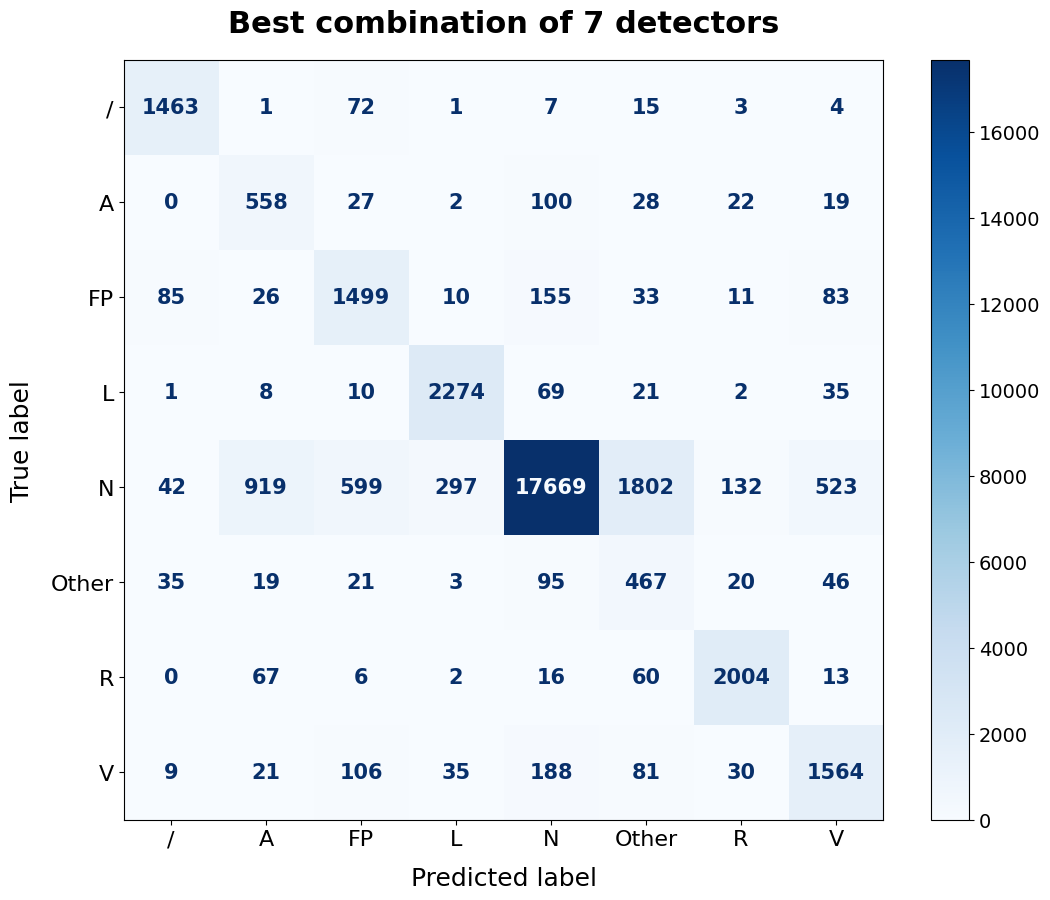

,metric,value
0,accuracy,0.819979
1,balanced_accuracy,0.819828


,class,sensitivity,specificity
0,/,0.934227,0.994620
1,A,0.738095,0.967632
2,FP,0.788118,0.973414
3,L,0.939669,0.988751
4,N,0.803757,0.945464
5,Other,0.661473,0.937860
6,R,0.924354,0.992986
7,V,0.768928,0.977048


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    multilabel_confusion_matrix,
)

classes = classifier.classes_

# Overall metrics
accuracy = accuracy_score(
    y_test,
    test_predictions,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions,
)

# Sensitivity = recall for each class
sensitivities = recall_score(
    y_test,
    test_predictions,
    labels=classes,
    average=None,
    zero_division=0,
)

# One-vs-rest confusion matrix for each class
class_confusion_matrices = multilabel_confusion_matrix(
    y_test,
    test_predictions,
    labels=classes,
)

specificities = []

for class_matrix in class_confusion_matrices:
    tn, fp, fn, tp = class_matrix.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    specificities.append(specificity)

# Plot
fig, ax = plt.subplots(figsize=(11, 9))

display_object = ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=classes,
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True,
)

# Numbers inside confusion-matrix cells
for text in display_object.text_.ravel():
    text.set_fontsize(15)
    text.set_fontweight("bold")

# Title
ax.set_title(
    "Best combination of 7 detectors",
    # "5 detectors from literature",
    # "All 41 detectors",
    fontsize=22,
    fontweight="bold",
    pad=20,
)

# Axis descriptions
ax.set_xlabel(
    "Predicted label",
    fontsize=18,
    labelpad=12,
)

ax.set_ylabel(
    "True label",
    fontsize=18,
    labelpad=12,
)

# Class names on both axes
ax.tick_params(
    axis="both",
    labelsize=16,
)

# Colorbar numbers
if display_object.im_.colorbar is not None:
    display_object.im_.colorbar.ax.tick_params(
        labelsize=14,
    )

plt.tight_layout()
plt.show()

# Metrics table
metrics_df = pd.DataFrame(
    {
        "class": classes,
        "sensitivity": sensitivities,
        "specificity": specificities,
    }
)

overall_metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "balanced_accuracy",
        ],
        "value": [
            accuracy,
            balanced_accuracy,
        ],
    }
)

display(overall_metrics_df)
display(metrics_df)

## Tree and feature importance

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    classifier,
    feature_names=SELECTED_FEATURES,
    class_names=[str(label) for label in classifier.classes_],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    ax=ax,
)

ax.set_title("Decision tree — first four levels")
plt.tight_layout()
plt.show()

feature_importance = (
    pd.Series(
        classifier.feature_importances_,
        index=SELECTED_FEATURES,
        name="importance",
    )
    .sort_values(ascending=False)
    .to_frame()
)

display(feature_importance)